In [1]:
%config InlineBackend.print_figure_kwargs = {'facecolor' : 'none'}

In [ ]:
import random
import operator
import catppuccin
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt
from langgraph_utils import console
from collections import deque, defaultdict
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Dict, List, Annotated

random.seed(42)
mpl.style.use(["dark_background", catppuccin.PALETTE.mocha.identifier])

In [3]:
class GraphState(TypedDict):
    nodes: int
    max_neighbors: int
    graph: Dict[str, List]
    max_depth: int

    queue: deque
    visited: Annotated[List, operator.add]
    current_level: int

    bfs_sequence: Annotated[List, operator.add]

In [4]:
def init_graph(state: GraphState):
    graph = defaultdict(list)

    for i in range(state["nodes"]):
        neighbors = min(random.randint(1, state["max_neighbors"]), state["nodes"] - 1)

        j = 0
        while j < neighbors:
            node = random.randint(0, state["nodes"] - 1)

            if i != node and node not in graph[i]:
                graph[i].append(node)
                # graph[node].append(i)
                j += 1

    return {"graph": graph, "queue": deque([0]), "visited": [0], "current_level": 0}


def process_level(state: GraphState):

    processing_size = len(state["queue"])
    current_frontier = deque(state["queue"])
    new_sequence, next_frontier, visited_nodes = [], deque(), set()

    for _ in range(processing_size):
        curr = current_frontier.popleft()
        new_sequence.append(curr)

        for neighbor in state["graph"][curr]:
            if neighbor not in state["visited"] and neighbor not in visited_nodes:
                next_frontier.append(neighbor)
                visited_nodes.add(neighbor)

    return {
        "bfs_sequence": new_sequence,
        "queue": next_frontier,
        "visited": list(visited_nodes),
        "current_level": state["current_level"] + 1,
    }


def check_depth_status(state: GraphState):
    if not state["queue"] or state["current_level"] > state["max_depth"]:
        return "stop"

    return "continue"

In [5]:
graph = StateGraph(GraphState)

In [6]:
graph.add_node("init_graph", init_graph)
graph.add_node("process_level", process_level)

In [7]:
graph.add_edge(START, "init_graph")
graph.add_edge("init_graph", "process_level")
graph.add_conditional_edges(
    "process_level", check_depth_status, {"stop": END, "continue": "process_level"}
)

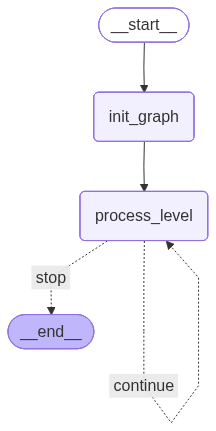

In [8]:
workflow = graph.compile()
workflow

In [9]:
final_state = workflow.invoke({"nodes": 30, "max_neighbors": 4, "max_depth": 4})

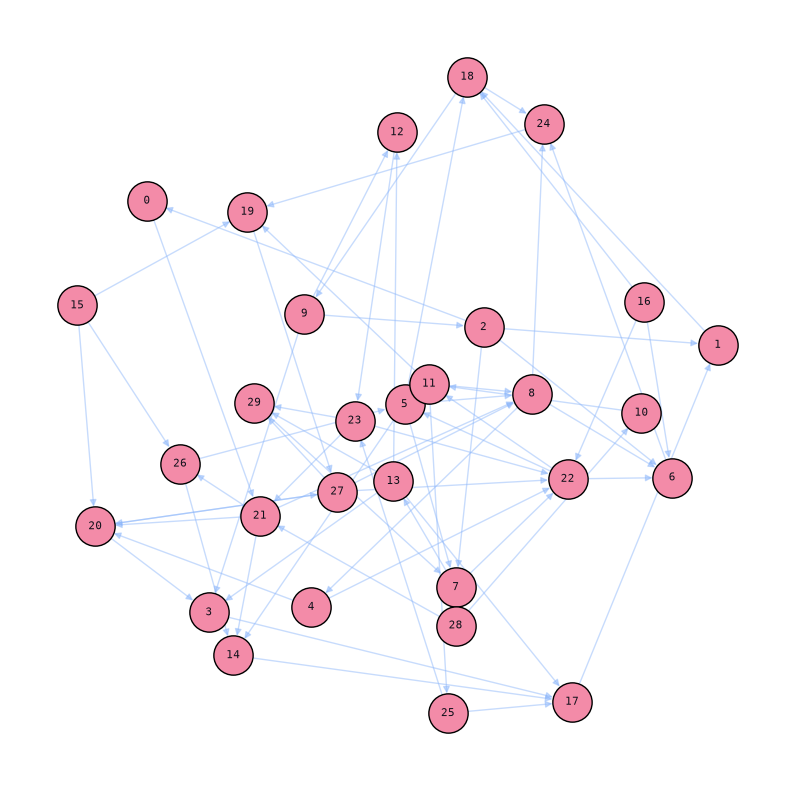

In [10]:
G = nx.DiGraph()

for node, neighbors in final_state["graph"].items():
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

mocha = catppuccin.PALETTE.mocha.colors

fig = plt.figure(figsize=(10, 10), facecolor=mocha.base.hex)
ax = plt.gca()

nx.draw(
    G,
    with_labels=True,
    node_size=800,
    node_color=mocha.red.hex,
    edge_color=f"{mocha.blue.hex}77",
    font_color=mocha.crust.hex,
    edgecolors="#000",
    linewidths=1,
    font_size=8,
    font_family="monospace",
    ax=ax,
)

plt.savefig("./files/graph.png")
plt.show()

In [11]:
console.print("BFS Sequence -> ", " ".join(str(x) for x in final_state["bfs_sequence"]))
console.print(f"Total nodes explored -> {len(final_state['bfs_sequence'])}")

BFS Sequence ->  0 21 8 14 20 26 4 6 24 17 27 3 5 22 19 1 29 7 18
Total nodes explored -> 19
